In [1]:
# Stage 1: Import Libraries
# Importing libraries for text processing, model training, and evaluation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [3]:
# Stage 2: Load Dataset
# Loading the emoji prediction dataset.

In [4]:
df = pd.read_csv("Train.csv")

In [5]:
df.head()

,Unnamed: 0,TEXT,Label
0,0,Vacation wasted ! #vacation2017 #photobomb #ti...,0
1,1,"Oh Wynwood, you’re so funny! : @user #Wynwood ...",1
2,2,Been friends since 7th grade. Look at us now w...,2
3,3,This is what it looks like when someone loves ...,3
4,4,RT @user this white family was invited to a Bl...,3


In [6]:
df.shape

(70000, 3)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  70000 non-null  int64 
 1   TEXT        70000 non-null  object
 2   Label       70000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.6+ MB


In [8]:
# Stage 3: Data Understanding
# Understanding emoji label distribution.

In [9]:
df['Label'].value_counts()

Label
9     15091
2      7076
3      6842
7      4363
15     3843
13     3250
16     2832
17     2751
1      2592
11     2434
14     2342
6      2083
8      1992
5      1977
12     1909
4      1878
19     1745
18     1722
10     1721
0      1557
Name: count, dtype: int64

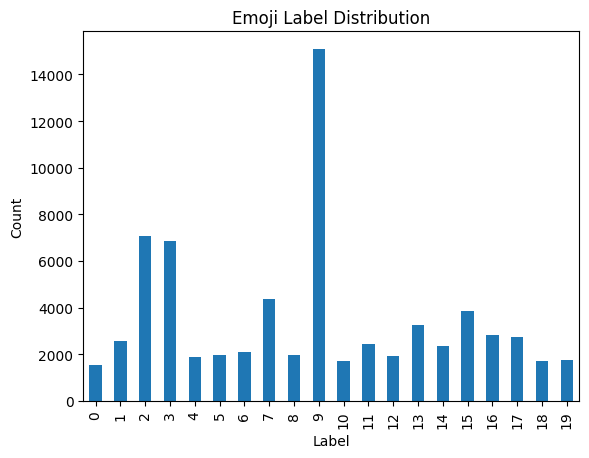

In [10]:
df['Label'].value_counts().sort_index().plot(kind='bar')

plt.title("Emoji Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

In [11]:
# Stage 4: Data Cleaning
# Checking missing values and duplicates.

In [12]:
df.isnull().sum()

Unnamed: 0    0
TEXT          0
Label         0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
# Stage 5: Feature & Target Separation
# Separating text and labels.

In [15]:
X = df['TEXT']

y = df['Label']

In [16]:
# Stage 6: TF-IDF Vectorization
# Converting text into numerical form.
# Machine learning models cannot understand raw text.

In [17]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X = tfidf.fit_transform(X)

In [18]:
# Stage 7: Train-Test Split
# Creating training and testing datasets.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
# Stage 8: Logistic Regression

In [21]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy")
print(
    accuracy_score(
        y_test,
        lr_pred
    )
)

Logistic Regression Accuracy
0.315


In [22]:
# Stage 9: Naive Bayes

In [23]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

print("Naive Bayes Accuracy")
print(
    accuracy_score(
        y_test,
        nb_pred
    )
)

Naive Bayes Accuracy
0.28964285714285715


In [24]:
# Stage 10: Random Forest

In [25]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy")
print(
    accuracy_score(
        y_test,
        rf_pred
    )
)

Random Forest Accuracy
0.296


In [26]:
# Stage 11: KNN

In [27]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN Accuracy")
print(
    accuracy_score(
        y_test,
        knn_pred
    )
)

KNN Accuracy
0.17114285714285715


In [28]:
# Stage 12: Model Comparison

In [29]:
results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'Random Forest',
        'KNN'
    ],

    'Accuracy': [

        accuracy_score(
            y_test,
            lr_pred
        ),

        accuracy_score(
            y_test,
            nb_pred
        ),

        accuracy_score(
            y_test,
            rf_pred
        ),

        accuracy_score(
            y_test,
            knn_pred
        )

    ]

})

results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,0.315000
2,Random Forest,0.296000
1,Naive Bayes,0.289643
3,KNN,0.171143


In [30]:
# Stage 13: Best Model Evaluation

# Use the model with highest accuracy.

In [31]:
print(
    confusion_matrix(
        y_test,
        lr_pred
    )
)

[[   1    1   27   69    3    1    2   18    0  150    0    2    4    4
     0    0    0    0    0    0]
 [   0   55   34   86    2    1   34   47    0  221    1    6    4   25
     0    2    5    2    1    5]
 [   0   15  318  132    1   13    5   38    2  802    0    8   15   17
     5    7   13   12    3    2]
 [   1   26   78  635    4   10    2   60    2  494    5   15    9   14
     5    4    5    7    1    7]
 [   0    3   34   78    1    5    2   21    1  188    1    0    6    7
     2    6    9    6    1    1]
 [   0    1   15   11    0  232    0    5    0  117    1    1    0    2
     0    0    0    2    0    0]
 [   0   37   34   58    2    1   17   23    0  217    1    1   14    9
     0    1   12    3    0    1]
 [   0   23   42  110    1    6    8  336    1  292    1    9    5   22
     0    4    9    1    0    5]
 [   0    5   39   42    0    5    1    9    6  246    0    2    0    5
     2    6    3    5    0    1]
 [   1   27  252  196    0   58    4   75    8 2246    

In [32]:
print(
    classification_report(
        y_test,
        lr_pred
    )
)

              precision    recall  f1-score   support

           0       0.20      0.00      0.01       282
           1       0.22      0.10      0.14       531
           2       0.25      0.23      0.24      1408
           3       0.33      0.46      0.38      1384
           4       0.04      0.00      0.01       372
           5       0.63      0.60      0.61       387
           6       0.19      0.04      0.07       431
           7       0.40      0.38      0.39       875
           8       0.21      0.02      0.03       377
           9       0.29      0.74      0.42      3049
          10       0.25      0.01      0.03       355
          11       0.69      0.43      0.53       509
          12       0.39      0.32      0.35       370
          13       0.31      0.15      0.20       644
          14       0.39      0.06      0.11       466
          15       0.21      0.03      0.06       728
          16       0.26      0.07      0.11       587
          17       0.12    

In [33]:
# Stage 14: Emoji Prediction
# Predicting emoji labels for new text.

In [34]:
sample_text = [

    "I am very happy today"

]

In [35]:
sample_vector = tfidf.transform(
    sample_text
)

prediction = lr.predict(
    sample_vector
)

print(prediction)

[9]


In [38]:
# Findings
# 1. The dataset contained 70,000 text samples mapped to 20 different emoji categories.
# 2. The data was converted into numerical features using TF-IDF Vectorization.
# 3. Multiple machine learning models were trained and compared for emoji prediction.
# 4. Logistic Regression achieved the highest accuracy of 31.50%, outperforming Random Forest, Naive Bayes, and KNN.
# 5. The dataset was highly imbalanced, with some emoji classes having significantly more samples than others.
# 6. The model performed best on frequently occurring emoji categories, especially Label 9.
# 7. The results demonstrate that textual content contains useful information for predicting emojis, although predicting among 20 different emoji classes remains a challenging task.

In [39]:
# Conclusion
# Successfully developed an emoji prediction system using text-based social media data.
# Applied TF-IDF vectorization to transform textual data into machine-readable features.
# Trained and evaluated Logistic Regression, Naive Bayes, Random Forest, and KNN models.
# Logistic Regression achieved the best performance with an accuracy of 31.50%.
# The project demonstrated how machine learning can be used to predict suitable emojis based on the context of a text message.
# The performance was affected by the large number of classes and the imbalance in emoji distribution, making the task more complex than 
# binary text classification problems such as spam detection or sentiment analysis.